# 实验二：图像增强

按顺序运行，使用已有 Conda `cv` 环境。输入图像从参考文档的 RGB 猫图中提取，详细说明见 README。

## 1. 导入依赖，查看运行环境

In [1]:
from pathlib import Path
import json
import sys
import time

import cv2
import numpy as np
import skimage
import matplotlib
import matplotlib.pyplot as plt
from skimage.util import random_noise

from image_ops import (
    read_color_image, to_uint8, filter_three_ways, manual_median_filter_color,
)
from plotting import show_grid

BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
if not (BASE_DIR / "p1.jpg").exists() and (BASE_DIR / "exp2" / "p1.jpg").exists():
    BASE_DIR = BASE_DIR / "exp2"
OUT = BASE_DIR / "output_images"
OUT.mkdir(parents=True, exist_ok=True)
print("Python:", sys.version.split()[0])
print("解释器:", sys.executable)
print("OpenCV:", cv2.__version__, "NumPy:", np.__version__)
print("scikit-image:", skimage.__version__, "Matplotlib:", matplotlib.__version__)
print("环境配置成功")

Python: 3.12.14
解释器: /opt/homebrew/anaconda3/envs/cv/bin/python
OpenCV: 5.0.0 NumPy: 2.5.3
scikit-image: 0.26.0 Matplotlib: 3.11.2
环境配置成功


## 2. 读取图像，BGR / RGB / 灰度转换

图像形状: (690, 690, 3) 数据类型: uint8
[100, 100] BGR: (84, 86, 241)
[100, 100] RGB: (241, 86, 84)
灰度值: 132


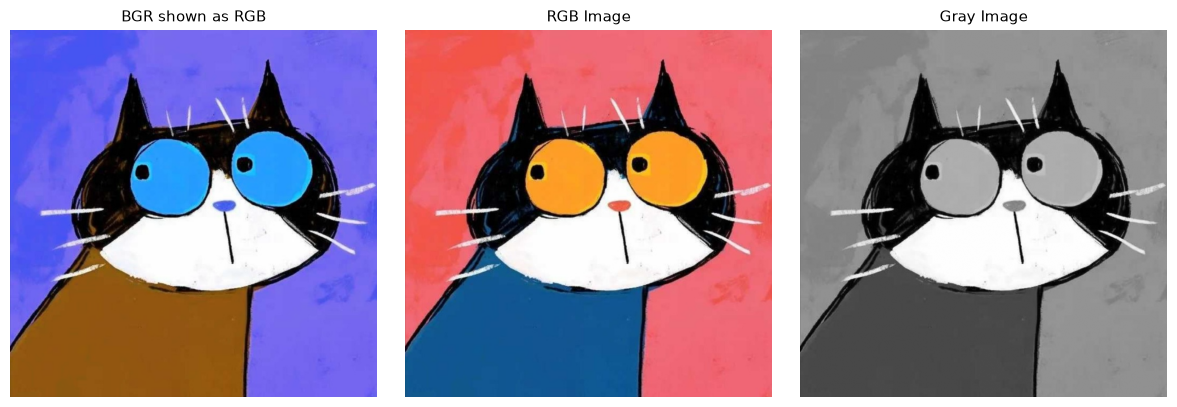

In [2]:
img = read_color_image(BASE_DIR / "p1.jpg")
rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
b, g, r = map(int, img[100, 100])
print("图像形状:", img.shape, "数据类型:", img.dtype)
print("[100, 100] BGR:", (b, g, r))
print("[100, 100] RGB:", tuple(map(int, rgb_img[100, 100])))
print("灰度值:", int(gray_img[100, 100]))
show_grid(
    [img, rgb_img, gray_img],
    ["BGR shown as RGB", "RGB Image", "Gray Image"],
    OUT / "01_color_spaces.png",
)

## 3. 添加椒盐噪声与高斯噪声

椒盐噪声: amount=0.4; 高斯噪声: mean=0.2, var=0.03


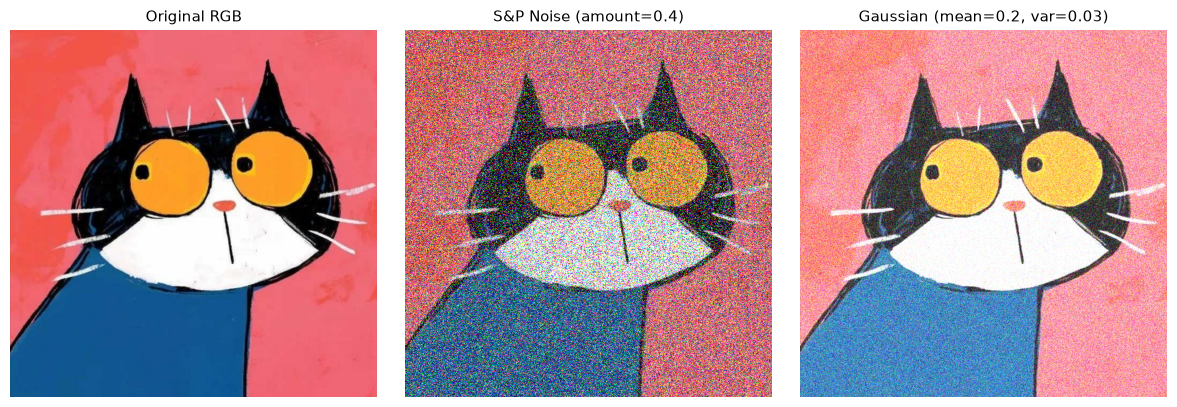

In [3]:
sp_noise_img = random_noise(rgb_img, mode="s&p", amount=0.4, rng=42)
gus_noise_img = random_noise(
    rgb_img, mode="gaussian", mean=0.2, var=0.03, rng=43,
)
sp_u8 = to_uint8(sp_noise_img)
gus_u8 = to_uint8(gus_noise_img)
print("椒盐噪声: amount=0.4; 高斯噪声: mean=0.2, var=0.03")
show_grid(
    [rgb_img, sp_noise_img, gus_noise_img],
    ["Original RGB", "S&P Noise (amount=0.4)", "Gaussian (mean=0.2, var=0.03)"],
    OUT / "02_noise_comparison.png",
)

## 4. 对两类噪声分别进行三种滤波

六组结果使用相同的 5×5 窗口和 uint8 输入


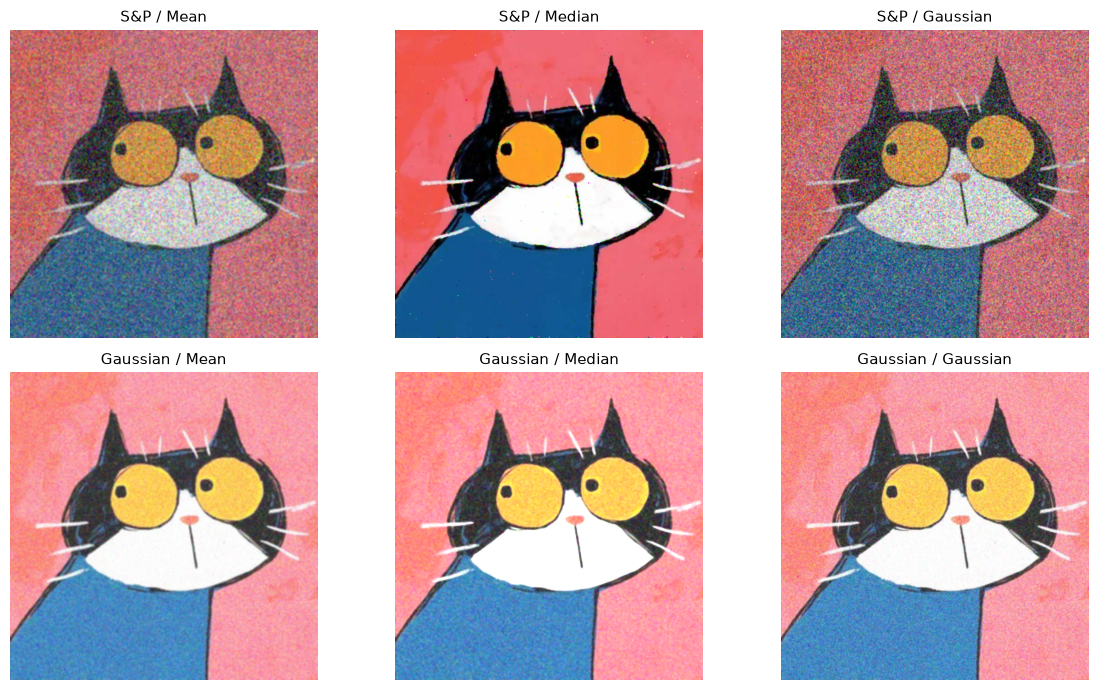

In [4]:
mean_sp, mid_sp, gauss_sp = filter_three_ways(sp_u8, kernel_size=5)
mean_gus, mid_gus, gauss_gus = filter_three_ways(gus_u8, kernel_size=5)
print("六组结果使用相同的 5×5 窗口和 uint8 输入")
show_grid(
    [mean_sp, mid_sp, gauss_sp, mean_gus, mid_gus, gauss_gus],
    ["S&P / Mean", "S&P / Median", "S&P / Gaussian",
     "Gaussian / Mean", "Gaussian / Median", "Gaussian / Gaussian"],
    OUT / "03_filter_results_2x3.png", rows=2, figsize=(12, 7),
)

## 5. 手写彩色中值滤波，并对比 OpenCV

手写中值滤波耗时: 5.41 秒
与 OpenCV 中值滤波逐像素相同: True
最大像素差: 0


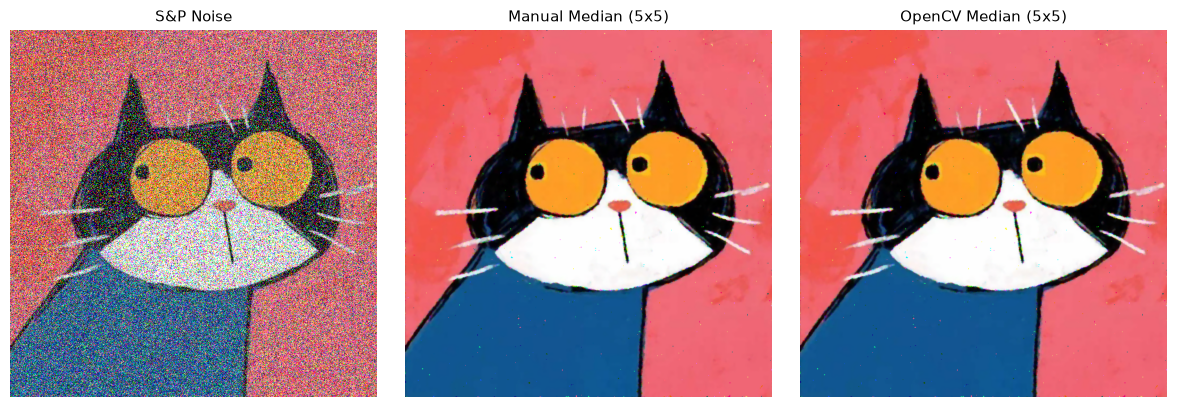

In [5]:
start = time.perf_counter()
manual_mid = manual_median_filter_color(sp_u8, kernel_size=5)
elapsed = time.perf_counter() - start
max_difference = int(np.max(np.abs(manual_mid.astype(np.int16) - mid_sp.astype(np.int16))))
print(f"手写中值滤波耗时: {elapsed:.2f} 秒")
print("与 OpenCV 中值滤波逐像素相同:", np.array_equal(manual_mid, mid_sp))
print("最大像素差:", max_difference)
show_grid(
    [sp_noise_img, manual_mid, mid_sp],
    ["S&P Noise", "Manual Median (5x5)", "OpenCV Median (5x5)"],
    OUT / "04_manual_median.png",
)

## 6. 保存实际运行信息

In [6]:
run_info = {
    "python": sys.version.split()[0], "opencv": cv2.__version__,
    "numpy": np.__version__, "scikit_image": skimage.__version__,
    "matplotlib": matplotlib.__version__, "image_shape": list(img.shape),
    "pixel_bgr_100_100": [b, g, r],
    "pixel_rgb_100_100": [int(v) for v in rgb_img[100, 100]],
    "gray_100_100": int(gray_img[100, 100]),
    "sp_amount": 0.4, "gaussian_mean": 0.2, "gaussian_var": 0.03,
    "random_seeds": [42, 43], "kernel_size": 5,
    "manual_equals_opencv": bool(np.array_equal(manual_mid, mid_sp)),
    "manual_max_pixel_difference": max_difference,
}
(OUT / "run_info.json").write_text(json.dumps(run_info, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
print("实验完成，结果保存在 output_images")

实验完成，结果保存在 output_images
